In [15]:
#Requirements
import tensorflow as tf
import numpy as np
import os
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense,Conv2D,Flatten,MaxPooling2D,BatchNormalization,Dropout,Input
from keras.regularizers import l2
from keras.initializers import HeNormal

In [16]:
classes=sorted(os.listdir(r'/kaggle/input/handwritten-characters/Train'))

In [17]:
#Data loading and preprocessing
train_data=tf.keras.utils.image_dataset_from_directory(
    r'/kaggle/input/handwritten-characters/Train',
    image_size=(32,32),
    batch_size=512,
    color_mode='grayscale',
    label_mode='categorical'
).map(lambda x,y:(x/255,y))

val_data=tf.keras.utils.image_dataset_from_directory(
    r'/kaggle/input/handwritten-characters/Validation',
    image_size=(32,32),
    batch_size=512,
    color_mode='grayscale',
    label_mode='categorical'
).map(lambda x,y:(x/255,y))

Found 834036 files belonging to 39 classes.
Found 22524 files belonging to 39 classes.


In [18]:
test_data=val_data.take(int(len(val_data)*0.3))

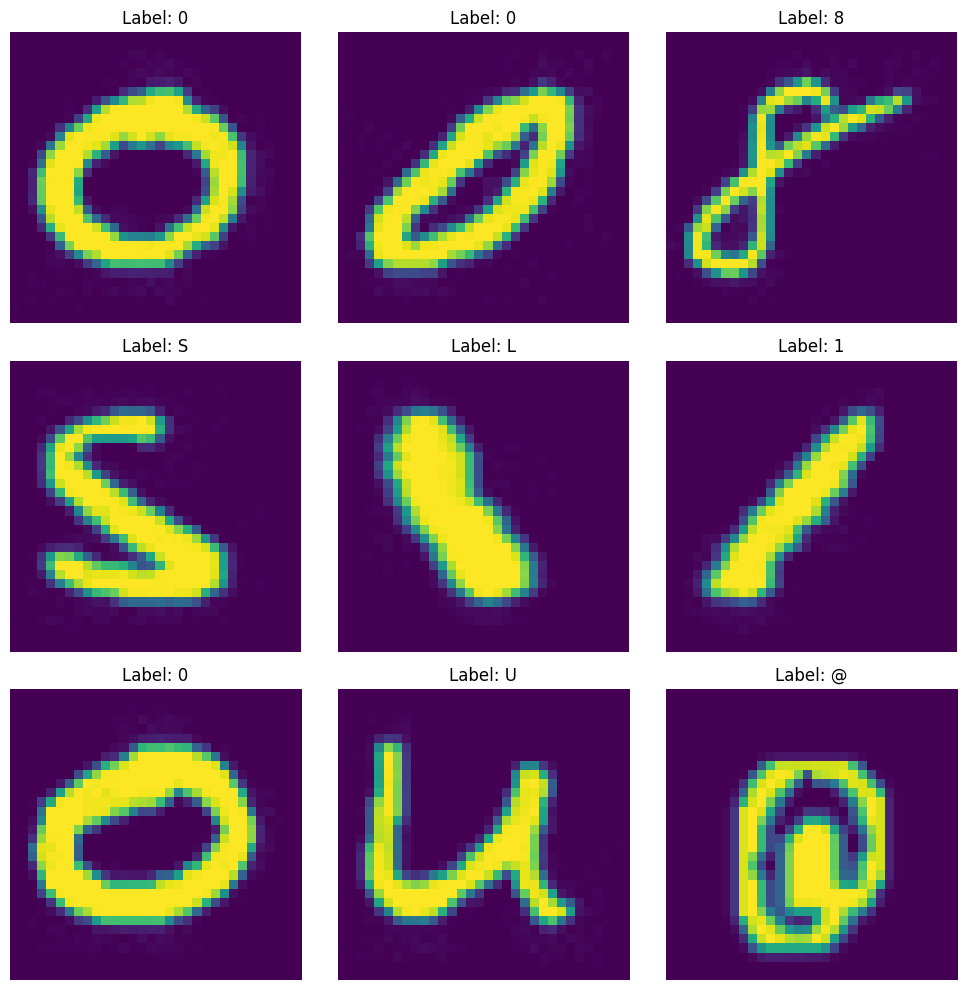

In [20]:
#Lets see the images
images, labels = (train_data.as_numpy_iterator()).next()

# Plot the first few images
plt.figure(figsize=(10, 10))
for i in range(9):  # Display first 9 images
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title(f"Label: {classes[np.argmax(labels[i])]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [21]:
#Model
model=Sequential([
    Input(shape=(32,32,1)),
    
    Conv2D(16,(3,3),padding='same',activation='relu',kernel_initializer=HeNormal(),kernel_regularizer=l2(1e-5)),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(32,(3,3),padding='same',activation='relu',kernel_initializer=HeNormal(),kernel_regularizer=l2(1e-5)),
    BatchNormalization(),
    MaxPooling2D(),

    Flatten(),

    Dense(32,activation='relu',kernel_regularizer=l2(1e-5)),
    BatchNormalization(),
    Dense(32,activation='relu',kernel_regularizer=l2(1e-5)),
    BatchNormalization(),
    Dense(39,activation='softmax')
])

#Compile
model.compile(optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'])

model.summary()

#Fitting(Training)
history=model.fit(train_data,epochs=20,validation_data=val_data,callbacks=[tf.keras.callbacks.EarlyStopping(patience=3,restore_best_weights=True,verbose=1,start_from_epoch=5)])

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 32, 32, 16)          │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 32, 32, 16)          │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 16, 16, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 16, 16, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 16, 16, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 8, 8, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 32)                  │          65,568 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 39)                  │           1,287 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 73,159 (285.78 KB)

 Trainable params: 72,935 (284.90 KB)

 Non-trainable params: 224 (896.00 B)

Epoch 1/20
1629/1629 ━━━━━━━━━━━━━━━━━━━━ 225s 134ms/step - accuracy: 0.8191 - loss: 0.7655 - val_accuracy: 0.9278 - val_loss: 0.2537
Epoch 2/20
1629/1629 ━━━━━━━━━━━━━━━━━━━━ 151s 93ms/step - accuracy: 0.9351 - loss: 0.2012 - val_accuracy: 0.9320 - val_loss: 0.2239
Epoch 3/20
1629/1629 ━━━━━━━━━━━━━━━━━━━━ 144s 88ms/step - accuracy: 0.9414 - loss: 0.1789 - val_accuracy: 0.9415 - val_loss: 0.2014
Epoch 4/20
1629/1629 ━━━━━━━━━━━━━━━━━━━━ 153s 94ms/step - accuracy: 0.9444 - loss: 0.1689 - val_accuracy: 0.9430 - val_loss: 0.1941
Epoch 5/20
1629/1629 ━━━━━━━━━━━━━━━━━━━━ 153s 94ms/step - accuracy: 0.9468 - loss: 0.1618 - val_accuracy: 0.9419 - val_loss: 0.1983
Epoch 6/20
1629/1629 ━━━━━━━━━━━━━━━━━━━━ 142s 87ms/step - accuracy: 0.9483 - loss: 0.1574 - val_accuracy: 0.9450 - val_loss: 0.1932
Epoch 7/20
1629/1629 ━━━━━━━━━━━━━━━━━━━━ 134s 82ms/step - accuracy: 0.9495 - loss: 0.1535 - val_accuracy: 0.9382 - val_loss: 0.2191
Epoch 8/20
1629/1629 ━━━━━━━━━━━━━━━━━━━━ 136s 83ms/step - accuracy:

In [22]:
#Saving
model.save('characters_model2.keras')

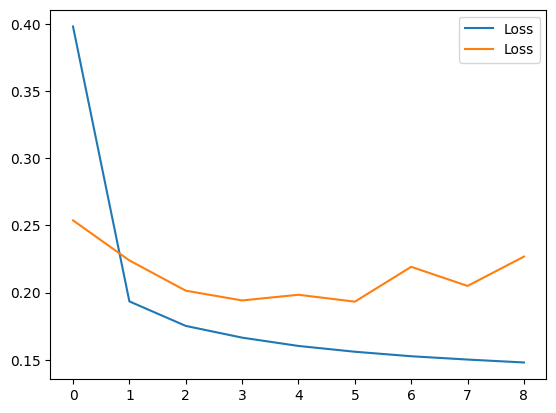

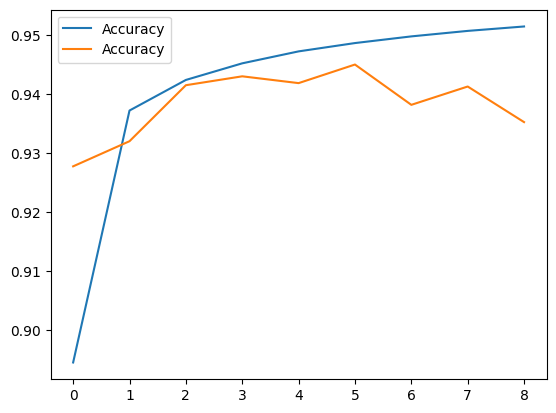

In [23]:
#Model performance
plt.plot(history.history['loss'],label='Loss')
plt.plot(history.history['val_loss'],label='Loss')
plt.legend()
plt.show()

plt.plot(history.history['accuracy'],label='Accuracy')
plt.plot(history.history['val_accuracy'],label='Accuracy')
plt.legend()
plt.show()

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step   
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 

Classification Report:
              precision    recall  f1-score   support

           #       1.00      1.00      1.00       401
           $       1.00      1.00      1.00       412
           &       1.00      0.99      1.00       137
           0       0.91      0.99      0.95       119
           1       0.90      0.99      0.94       506
           2       0.94      1.00      0.97       351
           3       0.99      1.00      0.99       383
           4       0.

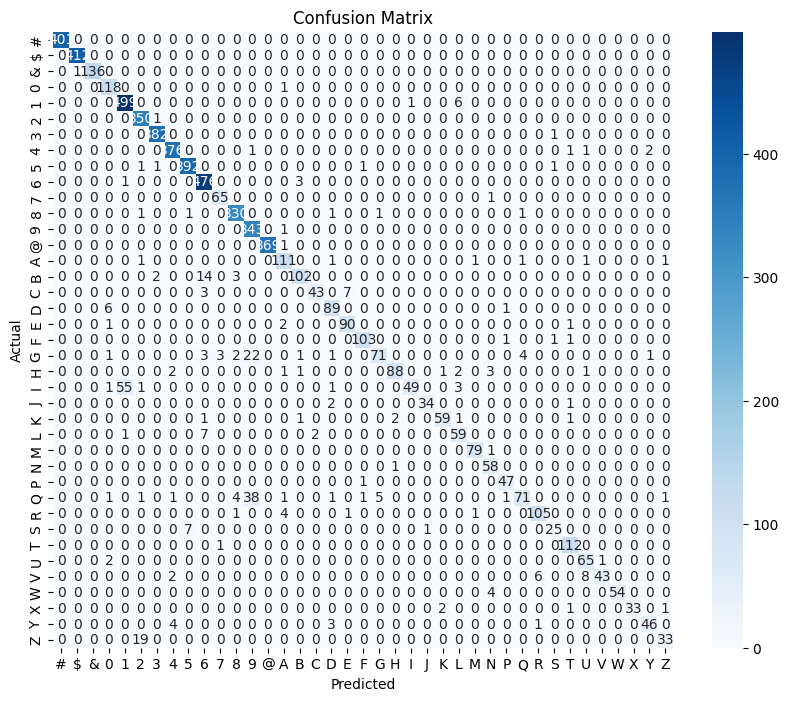

In [24]:
#Validating
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_true = []
y_pred = []

for images, labels in test_data:
    preds = model.predict(images)
    y_true.extend(np.argmax(labels.numpy(), axis=1))  # FIXED LINE
    y_pred.extend(np.argmax(preds, axis=1))



print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=classes))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
#Testing
model = tf.keras.models.load_model('characters.keras')

img_path = r''
img = tf.keras.preprocessing.image.load_img(img_path, target_size=(32, 32))  # Resize image to match the model input size

# Convert the image to a numpy array
img_array = tf.keras.preprocessing.image.img_to_array(img)

# Add an extra dimension (batch size of 1) as the model expects input in batches
img_array = np.expand_dims(img_array, axis=0)

# Normalize the image (if you did normalization during training, e.g., rescaling)
img_array = img_array / 255.0  # Assuming you scaled the images to [0,1] during training

# Predict the class of the image
predictions = model.predict(img_array)

# Get the predicted class index (for multi-class, you can get the index with the highest probability)
predicted_class_index = np.argmax(predictions, axis=1)

# Print the predicted class index (you can map this to the category name if needed)
print(f"Predicted Class Index: {classes[predicted_class_index]}")
